In [60]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass

# For reproducibility
rng = np.random.default_rng(42)

### Autocorrelated Returns

$ r_t = \phi\, r_{t-1} + \sigma\,\sqrt{\Delta t}\,\epsilon_t$ 


In [61]:
## VWAP ##
def vwap_schedule(X, N, dt, w):
    """ VWAP execution schedule.
    X: total shares to trade (positive for buy, negative for sell)
    N: number of time steps
    dt: time step size
    w: array of market volumes per time step (length N)
    Returns:
    x: array of shares remaining to trade at each time step (length N+1)
    v: array of shares to trade at each time step (length N)
    """
    W = np.sum(w)
    v = X * (w / W)  # shares to trade at each time step
    x = np.zeros(N + 1)
    x[0] = X
    for t in range(N):
        x[t + 1] = x[t] - v[t]
    return x, v
## TWAP ##
def twap_schedule(X, N, dt):
    """ TWAP execution schedule.
    X: total shares to trade (positive for buy, negative for sell)
    N: number of time steps
    dt: time step size
    Returns:
    x: array of shares remaining to trade at each time step (length N+1)
    v: array of shares to trade at each time step (length N)
    """
    v = np.full(N, X / N)  # equal shares to trade at each time step
    x = np.zeros(N + 1)
    x[0] = X
    for t in range(N):
        x[t + 1] = x[t] - v[t]
    return x, v

In [62]:
def u_shape_volume_profile(N, a=2.0, b=2.0):
    # Smooth U-shape using a beta-like curve mirrored around 0.5
    x = np.linspace(0, 1, N, endpoint=False) + 0.5/N
    w = (x*(1-x))**(min(a,b)-1)
    w = w / w.sum()
    return w

def sinusoid_volume_profile(N):
    x = np.arange(N)
    w = 0.6 + 0.4 * np.cos(2*np.pi*(x+0.5)/N)   # peak at open/close
    w = np.maximum(w, 0.01)
    w = w / w.sum()
    return w

In [63]:
S0 = 100.0        # initial price
phi = 0.8          # AR(1) on returns
T = 600              #liquidation time in secs
N = 600              # number of slices
dt = T/N        # time step size (in years)
paths= 2000         # Monte Carlo paths

In [64]:
X = 1_000.0  # shares to sell over the horizon

# Choose a volume profile for VWAP
w = sinusoid_volume_profile(N)

w_ushape = u_shape_volume_profile(N)

# Build schedules (deterministic ones use parameters; GS is path-dependent, so we'll compute during execution)
dt = dt
tgrid = np.arange(N+1) * dt
# TWAP / VWAP (deterministic schedules)
x_twap, v_twap = twap_schedule(X, N, dt)
x_vwap, v_vwap = vwap_schedule(X, N, dt, w)

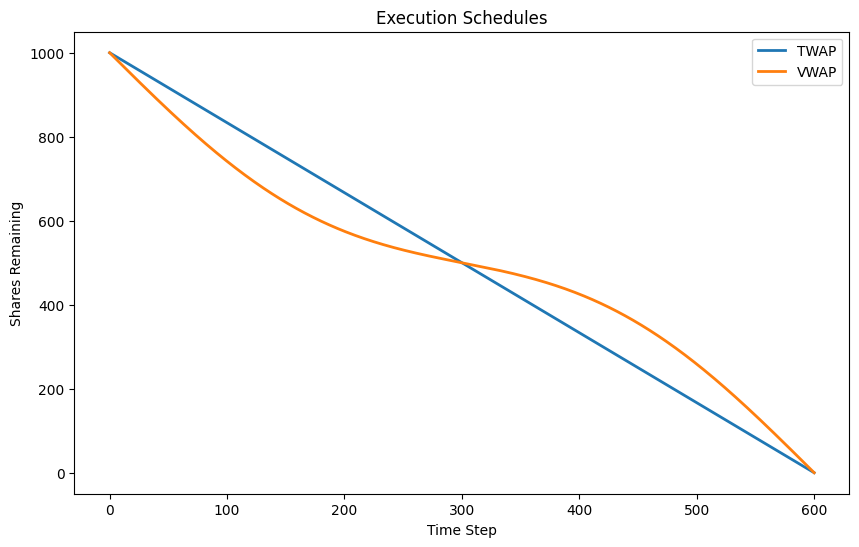

In [65]:
### Plot Execution Schedules ###
tgrid = np.arange(N+1) * dt

plt.figure(figsize=(10,6))
plt.plot(tgrid, x_twap, label="TWAP", lw=2)
plt.plot(tgrid, x_vwap, label="VWAP", lw=2)
plt.xlabel("Time Step")
plt.ylabel("Shares Remaining")
plt.title("Execution Schedules")
plt.legend()
plt.show() 

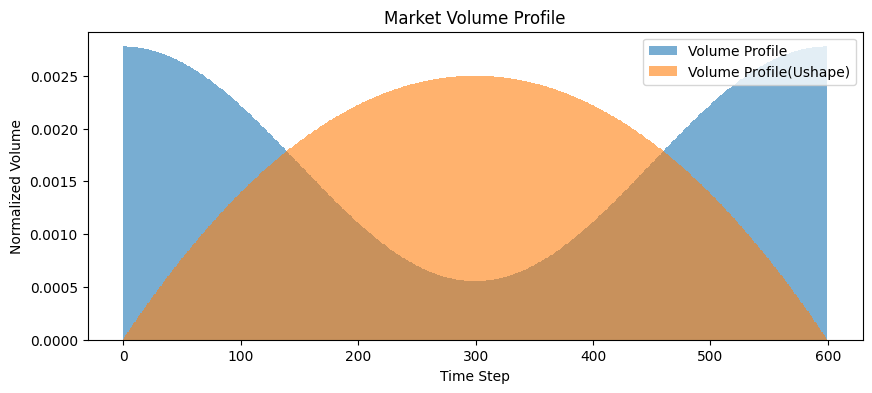

In [66]:
#plot volume profile
plt.figure(figsize=(10,4))
plt.bar(tgrid[:-1], w, width=dt, alpha=0.6, label="Volume Profile")
plt.bar(tgrid[:-1], w_ushape, width=dt, alpha=0.6, label="Volume Profile(Ushape)")
plt.xlabel("Time Step")
plt.ylabel("Normalized Volume")
plt.title("Market Volume Profile")
plt.legend()
plt.show()


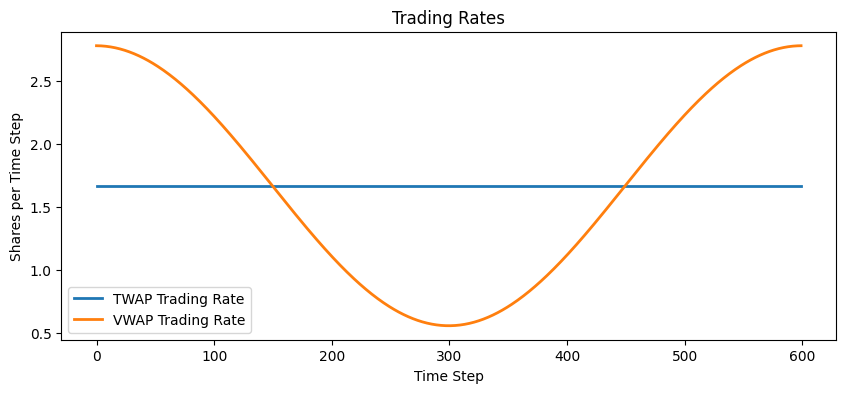

In [67]:
#plot trading rates
plt.figure(figsize=(10,4))
plt.plot(tgrid[:-1], v_twap, label="TWAP Trading Rate", lw=2)
plt.plot(tgrid[:-1], v_vwap, label="VWAP Trading Rate", lw=2)
plt.xlabel("Time Step")     
plt.ylabel("Shares per Time Step")
plt.title("Trading Rates")
plt.legend()
plt.show()

## Almgren Chriss 

Deterministic optimal schedule for inventory \(x(t)\) minimizing
  \($ \int (\eta \dot{x}^2 + \lambda \sigma^2 x^2) dt $\), yielding
  \[$ x(t) = X\,\frac{\sinh(\kappa (T-t))}{\sinh(\kappa T)}, \quad \kappa=\sqrt{\lambda\,\sigma^2/\eta}.$ \]
  Discretize to get trades \($v_t = -(x_{t+1}-x_t)/\Delta t$\).

In [68]:
## Almgren Chriss ##
def ac_schedule(X, N, dt, eta, lam, sigma):
    """ Almgren-Chriss execution schedule.
    X: total shares to trade (positive for buy, negative for sell)
    N: number of time steps
    dt: time step size
    eta: temporary impact parameter
    lam: risk aversion parameter
    sigma: volatility of the asset
    Returns:
    x: array of shares remaining to trade at each time step (length N+1)
    v: array of shares to trade at each time step (length N)
    """
    kappa = np.sqrt(lam * sigma**2 / eta)
    sinh_kappa_N = np.sinh(kappa * N * dt)
    x = np.zeros(N + 1)
    v = np.zeros(N)
    for t in range(N):
        x[t] = X * (np.sinh(kappa * (N - t) * dt) / sinh_kappa_N)
        v[t] = (x[t] - x[t + 1])
    x[N] = 0.0
    return x, v

In [69]:
x_ac, v_ac = ac_schedule(X, N, dt, eta=0.1, lam=0.1, sigma=0.02)

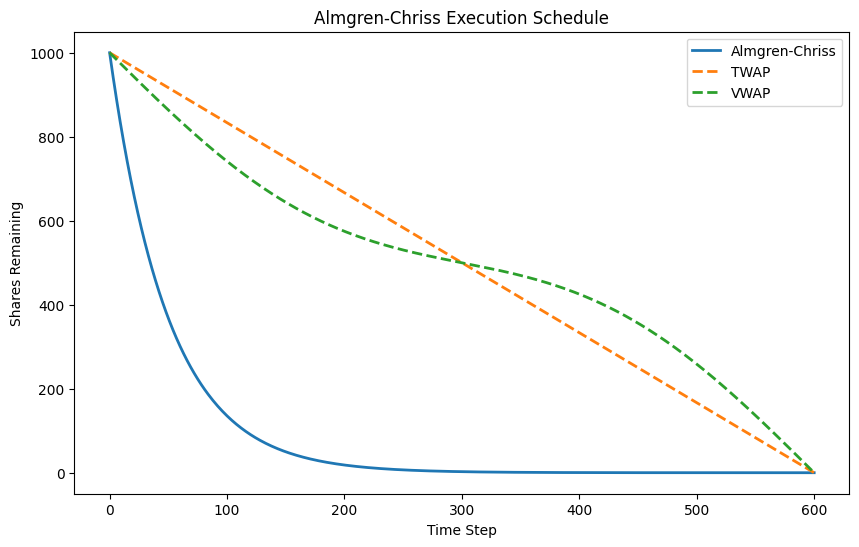

In [70]:
### Plot Almgren-Chriss Schedule for across lam ###

plt.figure(figsize=(10,6))
plt.plot(tgrid, x_ac, label="Almgren-Chriss", lw=2)
plt.plot(tgrid, x_twap, label="TWAP", lw=2, ls='--')
plt.plot(tgrid, x_vwap, label="VWAP", lw=2, ls='--')
plt.xlabel("Time Step")
plt.ylabel("Shares Remaining")
plt.title("Almgren-Chriss Execution Schedule") 
plt.legend()
plt.show()


In [71]:
def build_variance_matrix(sigma, times):
    """Covariance matrix of price innovations under arithmetic Brownian motion:
    Cov(i,j) = sigma^2 * min(t_i, t_j)\n    Returns Sigma (NxN).
    """
    times = np.asarray(times)
    N = len(times)
    Sigma = np.empty((N, N), dtype=float)
    for i in range(N):
        for j in range(N):
            Sigma[i, j] = sigma**2 * min(times[i], times[j])
    return Sigma

def solve_execution_qp(G, Sigma, lambd, X, dt=1.0, epsilon=1e-12):
    """Solve the discrete-time quadratic program for optimal trade schedule x (size N):
    minimize 0.5 * x' (2*G + 2*lambd*Sigma) x
    subject to sum(x) = X  (i.e., total shares to execute)
    The formulation treats x as trade sizes at each grid point.
    We solve the KKT system:
      [H   1] [x]   = [0]
      [1^T 0] [nu]    [X]
    where H = 2*(G + lambd*Sigma) and 1 is a column vector of ones.
    Returns x (trade sizes), Lagrange multiplier nu.
    """
    N = G.shape[0]
    H = 2.0 * (G + lambd * Sigma)
    # Regularize H slightly for numerical stability
    H += epsilon * np.eye(N)
    ones = np.ones((N,1))
    KKT = np.block([[H, ones], [ones.T, np.zeros((1,1))]])
    rhs = np.concatenate([np.zeros(N), np.array([X])])
    sol = np.linalg.solve(KKT, rhs)
    x = sol[:N]
    nu = sol[N]
    return x, nu

# Simple wrappers for industry models

def almgren_chriss_scheduler(times, sigma, eta, gamma, lambd, X):
    """Discrete-time Almgren-Chriss as a QP special case.
    AC cost kernel is typically instantaneous (eta on diag) + permanent impact (gamma)
    We approximate by constructing G with diagonal (temporary) and full (permanent) parts.
    """
    times = np.asarray(times)
    dt = np.diff(times, prepend=0.0)
    # Build G: temporary impact on diagonal, permanent as constant gamma/2 for all pairs
    N = len(times)
    G = np.zeros((N,N))
    for i in range(N):
        G[i,i] = eta / dt[i] if dt[i] > 0 else eta
    # permanent linear cost: model as gamma/2 for each cross term
    G += (gamma/2.0) * np.ones((N,N))
    Sigma = build_variance_matrix(sigma, times)
    return solve_execution_qp(G, Sigma, lambd, X, dt=dt.mean())

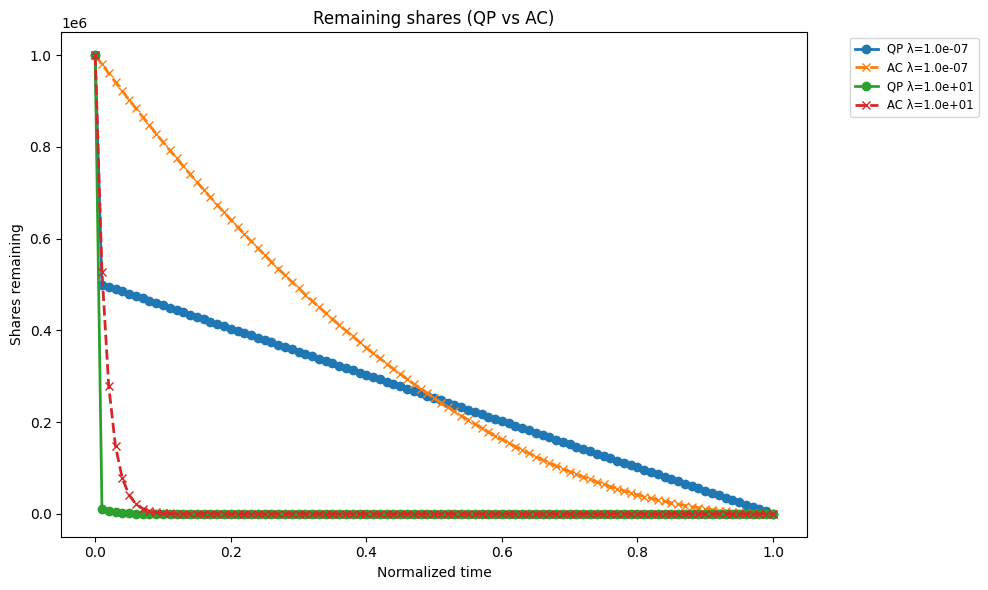

In [82]:
import numpy as np
import matplotlib.pyplot as plt

# example inputs (adapt to your notebook variables)
N = 100
T = 1.0
times = np.linspace(0, T, N)
sigma = 0.2     # 10x higher volatility
X = 1e6         # larger parent order
lambdas = np.logspace(-7, 1, 2)

eta = 1e-4
gamma = 1e-5
schedules_qp = []
schedules_ac_remaining = []   # AC returns remaining shares array (length N+1)
schedules_ac_v = []           # AC per-step trades (length N)

# build schedules
dt = float(times[1] - times[0]) if N > 1 else 1.0 / N

for lam in lambdas:
    # numeric QP schedule (your function) — adjust arg order if different in your notebook
    x_qp, nu = almgren_chriss_scheduler(times, sigma, eta, gamma, lam, X)
    schedules_qp.append(np.asarray(x_qp))

    # closed-form AC (call with the correct signature)
    try:
        # ac_schedule returns (x_remaining (N+1), v_per_step (N))
        x_ac_rem, v_ac = ac_schedule(X, N, dt, eta, lam, sigma)
        x_ac_rem = np.asarray(x_ac_rem)
        v_ac = np.asarray(v_ac)

        # Basic sanity checks: lengths
        if x_ac_rem.shape[0] != N + 1 or v_ac.shape[0] != N:
            raise ValueError(f"Unexpected AC return shapes: x_rem {x_ac_rem.shape}, v {v_ac.shape}")

        # Ensure sum consistency: v_ac should sum to X (tolerate tiny numeric error)
        sum_v = v_ac.sum()
        if abs(sum_v - X) > 1e-6 and sum_v != 0:
            v_ac = v_ac * (X / sum_v)
            x_ac_rem = np.concatenate([[X], X - np.cumsum(v_ac)])

        schedules_ac_remaining.append(x_ac_rem)
        schedules_ac_v.append(v_ac)
    except Exception as e:
        # If ac_schedule fails for this lambda, append None placeholders and continue
        print(f"ac_schedule failed for lambda={lam:.1e}: {e}")
        schedules_ac_remaining.append(None)
        schedules_ac_v.append(None)

# Plot remaining shares (QP vs AC)
plt.figure(figsize=(10, 6))
for i, lam in enumerate(lambdas):
    x_qp = np.asarray(schedules_qp[i])
    remaining_qp = X - np.cumsum(x_qp)      # remaining AFTER each trade (length N)
    # For plotting aligned with AC's x_rem (length N+1), prepend initial X
    remaining_qp_plot = np.concatenate([[X], remaining_qp])[:N+1]  # length N+1
    plt.plot(np.linspace(0, 1, N+1), remaining_qp_plot, marker='o', lw=2, label=f"QP λ={lam:.1e}")

    x_ac_rem = schedules_ac_remaining[i]
    if x_ac_rem is not None:
        plt.plot(np.linspace(0, 1, N+1), x_ac_rem, '--', marker='x', lw=2, label=f"AC λ={lam:.1e}")

plt.title("Remaining shares (QP vs AC)")
plt.xlabel("Normalized time")
plt.ylabel("Shares remaining")
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




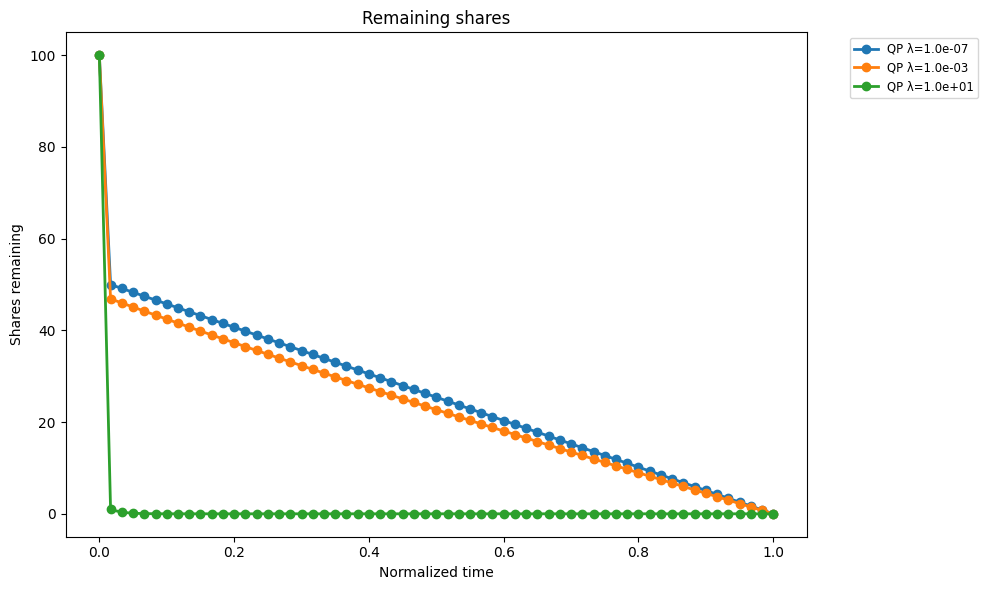

In [92]:
### QP schedules for multiple levels of risk aversion ###
import numpy as np
import matplotlib.pyplot as plt

# example inputs (adapt to your notebook variables)
N = 60
T = 1.0
times = np.linspace(0, T, N)
sigma = 0.2     # 10x higher volatility
X = 100        # larger parent order
lambdas = np.logspace(-7, 1, 3)

eta = 1e-4
gamma = 1e-5
schedules_qp = []

# build schedules
dt = float(times[1] - times[0]) if N > 1 else 1.0 / N

for lam in lambdas:
    # numeric QP schedule (your function) — adjust arg order if different in your notebook
    x_qp, nu = almgren_chriss_scheduler(times, sigma, eta, gamma, lam, X)
    schedules_qp.append(np.asarray(x_qp))

# Plot remaining shares (QP vs AC)
plt.figure(figsize=(10, 6))
for i, lam in enumerate(lambdas):
    x_qp = np.asarray(schedules_qp[i])
    remaining_qp = X - np.cumsum(x_qp)      # remaining AFTER each trade (length N)
    # For plotting aligned with AC's x_rem (length N+1), prepend initial X
    remaining_qp_plot = np.concatenate([[X], remaining_qp])[:N+1]  # length N+1
    plt.plot(np.linspace(0, 1, N+1), remaining_qp_plot, marker='o', lw=2, label=f"QP λ={lam:.1e}")


plt.title("Remaining shares")
plt.xlabel("Normalized time")
plt.ylabel("Shares remaining")
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

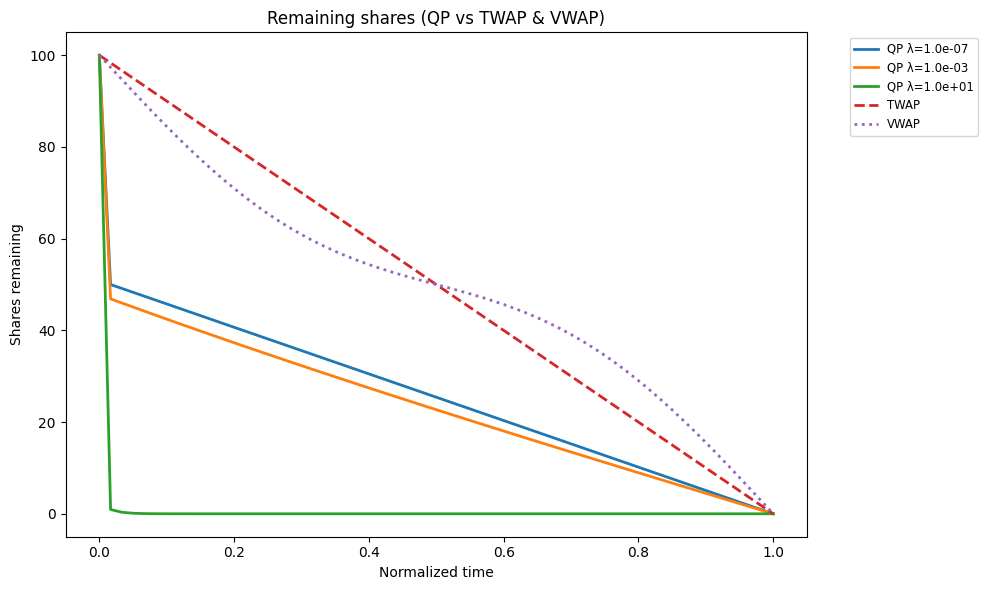

In [93]:
### QP schedules for multiple levels of risk aversion + TWAP & VWAP ###
import numpy as np
import matplotlib.pyplot as plt

# example inputs (adapt to your notebook variables)
N = 60
T = 1.0
times = np.linspace(0, T, N)
dt = float(times[1] - times[0]) if N > 1 else 1.0 / N

sigma  = 0.2
X      = 100
lambdas = np.logspace(-7, 1, 3)

eta = 1e-4
gamma = 1e-5

schedules_qp = []

# ---- Build QP schedules for each lambda ----
for lam in lambdas:
    x_qp, nu = almgren_chriss_scheduler(times, sigma, eta, gamma, lam, X)
    schedules_qp.append(np.asarray(x_qp))

# ---- TWAP schedule (per-step trades) ----
x_twap = np.full(N, X / N, dtype=float)

# ---- VWAP schedule (per-step trades) ----
# U-shaped intraday volume profile (high at open/close, low mid-day)
t01 = (times - times.min()) / (times.max() - times.min() + 1e-12)  # normalize to [0,1]
vol_profile = 1.0 + 0.6 * np.cos(2 * np.pi * t01)  # > 0, U-shaped
weights = vol_profile / vol_profile.sum()
x_vwap = X * weights  # proportional to expected market volume each step

# ---- Plot remaining shares (QP vs TWAP & VWAP) ----
plt.figure(figsize=(10, 6))

# QP schedules
for i, lam in enumerate(lambdas):
    x_qp = schedules_qp[i]
    remaining_qp = X - np.cumsum(x_qp)
    remaining_qp_plot = np.concatenate([[X], remaining_qp])[:N+1]
    plt.plot(np.linspace(0, 1, N+1), remaining_qp_plot, lw=2, label=f"QP λ={lam:.1e}")

# TWAP remaining
remaining_twap = X - np.cumsum(x_twap)
remaining_twap_plot = np.concatenate([[X], remaining_twap])[:N+1]
plt.plot(np.linspace(0, 1, N+1), remaining_twap_plot, '--', lw=2, label="TWAP")

# VWAP remaining
remaining_vwap = X - np.cumsum(x_vwap)
remaining_vwap_plot = np.concatenate([[X], remaining_vwap])[:N+1]
plt.plot(np.linspace(0, 1, N+1), remaining_vwap_plot, ':', lw=2, label="VWAP")

plt.title("Remaining shares (QP vs TWAP & VWAP)")
plt.xlabel("Normalized time")
plt.ylabel("Shares remaining")
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
